# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Read dataset

In [2]:
df=pd.read_csv("/kaggle/input/bigmart-sales-data/Test.csv")
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3
...,...,...,...,...,...,...,...,...,...,...,...
5676,FDB58,10.500,Regular,0.013496,Snack Foods,141.3154,OUT046,1997,Small,Tier 1,Supermarket Type1
5677,FDD47,7.600,Regular,0.142991,Starchy Foods,169.1448,OUT018,2009,Medium,Tier 3,Supermarket Type2
5678,NCO17,10.000,Low Fat,0.073529,Health and Hygiene,118.7440,OUT045,2002,NaN,Tier 2,Supermarket Type1
5679,FDJ26,15.300,Regular,0.000000,Canned,214.6218,OUT017,2007,NaN,Tier 2,Supermarket Type1


# Explore the dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   object 
 1   Item_Weight                4705 non-null   float64
 2   Item_Fat_Content           5681 non-null   object 
 3   Item_Visibility            5681 non-null   float64
 4   Item_Type                  5681 non-null   object 
 5   Item_MRP                   5681 non-null   float64
 6   Outlet_Identifier          5681 non-null   object 
 7   Outlet_Establishment_Year  5681 non-null   int64  
 8   Outlet_Size                4075 non-null   object 
 9   Outlet_Location_Type       5681 non-null   object 
 10  Outlet_Type                5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB


In [4]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
count,4705.000000,5681.000000,5681.000000,5681.000000
mean,12.695633,0.065684,141.023273,1997.828903
std,4.664849,0.051252,61.809091,8.372256
min,4.555000,0.000000,31.990000,1985.000000
25%,8.645000,0.027047,94.412000,1987.000000
50%,12.500000,0.054154,141.415400,1999.000000
75%,16.700000,0.093463,186.026600,2004.000000
max,21.350000,0.323637,266.588400,2009.000000


In [5]:
df.describe(include="O")

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,5681,5681,5681,5681,4075,5681,5681
unique,1543,5,16,10,3,3,4
top,DRF48,Low Fat,Snack Foods,OUT027,Medium,Tier 3,Supermarket Type1
freq,8,3396,789,624,1862,2233,3717


In [6]:
df.isna().sum()

Item_Identifier                 0
Item_Weight                   976
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

In [7]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'low fat': 'Low Fat',
    'LF': 'Low Fat' ,
    'reg' : 'Regular'
})


In [8]:
df.groupby('Item_Fat_Content')['Item_Weight'].mean().to_frame()

,Item_Weight
Item_Fat_Content,
Low Fat,12.860395
Regular,12.394528


In [9]:
df["Item_Weight"]=df["Item_Weight"].fillna(df["Item_Weight"].mean())

In [10]:
df["Outlet_Size"]=df["Outlet_Size"].fillna(df["Outlet_Size"].mode()[0])

In [11]:
df.isna().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
dtype: int64

In [12]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750000,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300000,Regular,0.038428,Dairy,87.3198,OUT017,2007,Medium,Tier 2,Supermarket Type1
2,NCN55,14.600000,Low Fat,0.099575,Others,241.7538,OUT010,1998,Medium,Tier 3,Grocery Store
3,FDQ58,7.315000,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,Medium,Tier 2,Supermarket Type1
4,FDY38,12.695633,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3
...,...,...,...,...,...,...,...,...,...,...,...
5676,FDB58,10.500000,Regular,0.013496,Snack Foods,141.3154,OUT046,1997,Small,Tier 1,Supermarket Type1
5677,FDD47,7.600000,Regular,0.142991,Starchy Foods,169.1448,OUT018,2009,Medium,Tier 3,Supermarket Type2
5678,NCO17,10.000000,Low Fat,0.073529,Health and Hygiene,118.7440,OUT045,2002,Medium,Tier 2,Supermarket Type1
5679,FDJ26,15.300000,Regular,0.000000,Canned,214.6218,OUT017,2007,Medium,Tier 2,Supermarket Type1


# Visualization dataset

In [13]:
df["Item_Fat_Content"].value_counts().to_frame()


,count
Item_Fat_Content,
Low Fat,3668
Regular,2013


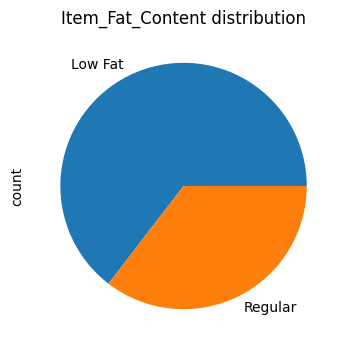

In [14]:
plt.figure(figsize=(6,4))
df["Item_Fat_Content"].value_counts().plot(kind="pie")
plt.title("Item_Fat_Content distribution")
plt.show()

In [15]:
df["Item_Type"].value_counts().to_frame()

,count
Item_Type,
Snack Foods,789
Fruits and Vegetables,781
Household,638
Frozen Foods,570
Dairy,454
Baking Goods,438
Canned,435
Health and Hygiene,338
Meat,311


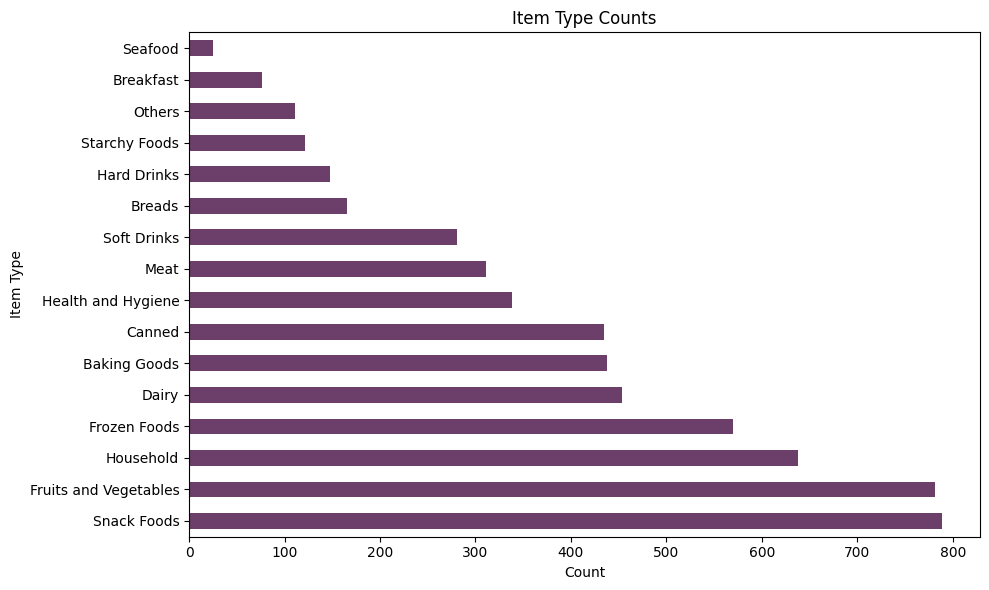

In [16]:
plt.figure(figsize=(10, 6))
df["Item_Type"].value_counts().plot(kind="barh", color="#6B3F69")
plt.xlabel("Count")
plt.ylabel("Item Type")
plt.title("Item Type Counts")
plt.tight_layout()
plt.show()

In [17]:
df["Outlet_Establishment_Year"].value_counts().to_frame()

,count
Outlet_Establishment_Year,
1985,976
1987,621
1999,620
1997,620
2004,620
2002,619
2009,618
2007,617
1998,370


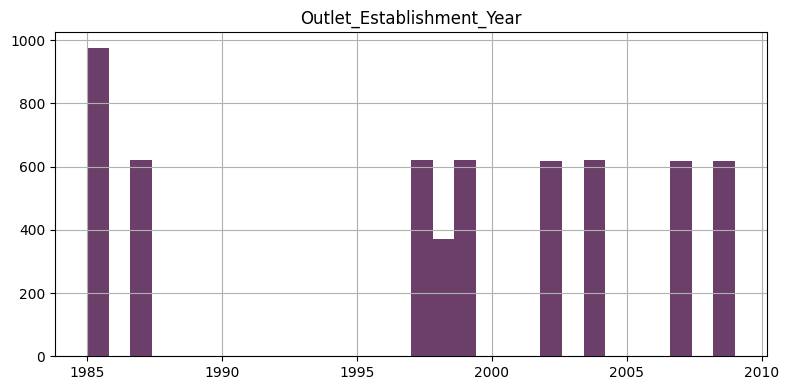

In [18]:
numeric_cols = ["Outlet_Establishment_Year"]
df[numeric_cols].hist(bins=30, figsize=(8,4),color="#6B3F69")
plt.tight_layout()
plt.show()

In [19]:
df["Outlet_Size"].value_counts().to_frame()

,count
Outlet_Size,
Medium,3468
Small,1592
High,621


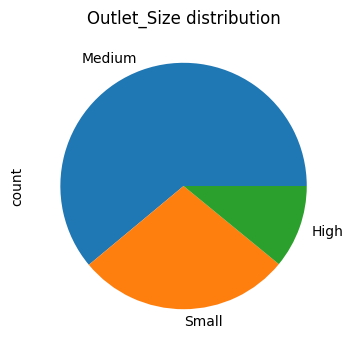

In [20]:
plt.figure(figsize=(6,4))
df["Outlet_Size"].value_counts().plot(kind="pie")
plt.title("Outlet_Size distribution")
plt.show()

In [21]:
df["Outlet_Location_Type"].value_counts().to_frame()

,count
Outlet_Location_Type,
Tier 3,2233
Tier 2,1856
Tier 1,1592


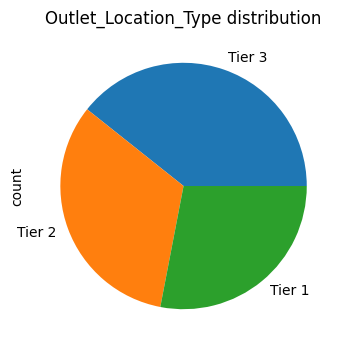

In [22]:
plt.figure(figsize=(6,4))
df["Outlet_Location_Type"].value_counts().plot(kind="pie")
plt.title("Outlet_Location_Type distribution")
plt.show()

In [23]:
df["Outlet_Type"].value_counts().to_frame()

,count
Outlet_Type,
Supermarket Type1,3717
Grocery Store,722
Supermarket Type3,624
Supermarket Type2,618


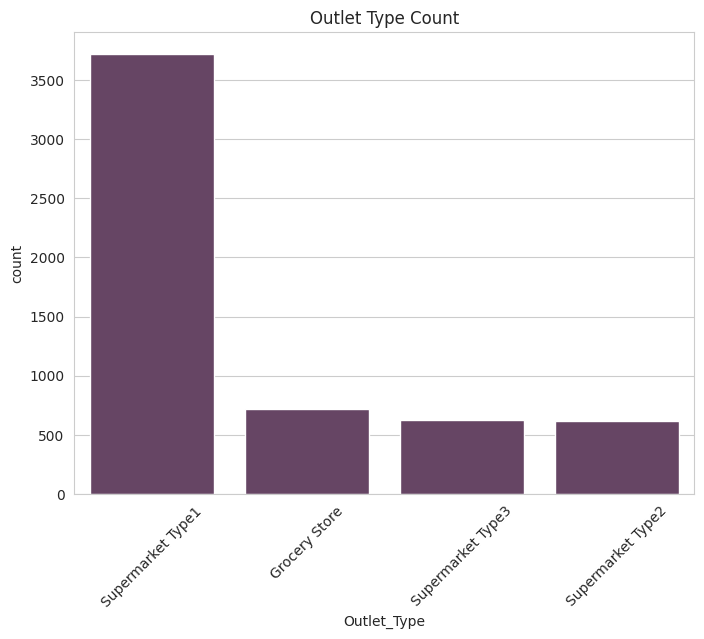

In [24]:
plt.figure(figsize=(8,6))
sns.set_style("whitegrid")
sns.countplot(x="Outlet_Type", data=df, color="#6B3F69")
plt.xticks(rotation=45)
plt.title("Outlet Type Count")
plt.show()

# Mapping dataset

In [25]:
df["Item_Fat_Content"]=df["Item_Fat_Content"].map({"Low Fat":"LF","Regular":"Reg"})

In [26]:
df["Outlet_Size"]=df["Outlet_Size"].map({"Small":0,"High":1,"Medium":2})

In [27]:
df["Outlet_Location_Type"]=df["Outlet_Location_Type"].map({"Tier 1":1,"Tier 2":2,"Tier 3":3})

In [28]:
df["Outlet_Type"]=df["Outlet_Type"].map({"Supermarket Type1":1,"Supermarket Type2":2,"Supermarket Type3":3,"Grocery Store":"GS"})

In [29]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750000,LF,0.007565,Snack Foods,107.8622,OUT049,1999,2,1,1
1,FDW14,8.300000,Reg,0.038428,Dairy,87.3198,OUT017,2007,2,2,1
2,NCN55,14.600000,LF,0.099575,Others,241.7538,OUT010,1998,2,3,GS
3,FDQ58,7.315000,LF,0.015388,Snack Foods,155.0340,OUT017,2007,2,2,1
4,FDY38,12.695633,Reg,0.118599,Dairy,234.2300,OUT027,1985,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...
5676,FDB58,10.500000,Reg,0.013496,Snack Foods,141.3154,OUT046,1997,0,1,1
5677,FDD47,7.600000,Reg,0.142991,Starchy Foods,169.1448,OUT018,2009,2,3,2
5678,NCO17,10.000000,LF,0.073529,Health and Hygiene,118.7440,OUT045,2002,2,2,1
5679,FDJ26,15.300000,Reg,0.000000,Canned,214.6218,OUT017,2007,2,2,1
